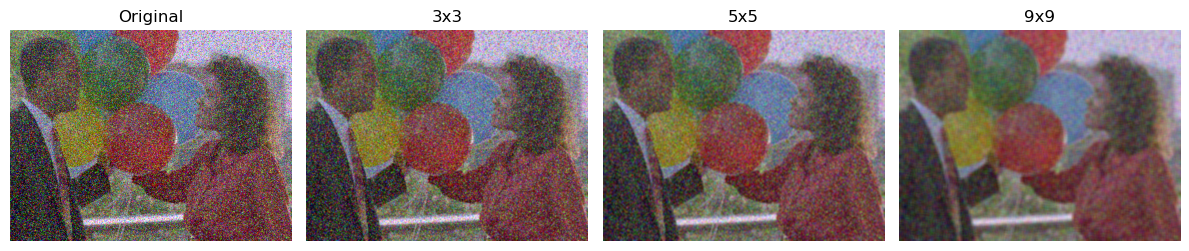

In [1]:
import cv2

import matplotlib.pyplot as plt

image = cv2.imread("/Users/230166/Desktop/balloons_noisy.png")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

blur_3 = cv2.blur(image, (3, 3))
blur_5 = cv2.blur(image, (5, 5))
blur_9 = cv2.blur(image, (9, 9))

plt.figure(figsize=(12, 6))

plt.subplot(1, 4, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(blur_3)
plt.title("3x3")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(blur_5)
plt.title("5x5")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(blur_9)
plt.title("9x9")
plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
import cv2

img = cv2.imread("/Users/230166/Desktop/balloons_noisy.png")

# Same kernel size
ksize = (31, 31)

# Small sigma
blur_sigma1 = cv2.GaussianBlur(img, ksize, 1)

# Medium sigma
blur_sigma5 = cv2.GaussianBlur(img, ksize, 5)

# Large sigma
blur_sigma15 = cv2.GaussianBlur(img, ksize, 15)

cv2.imshow("Sigma 1", blur_sigma1)
cv2.imshow("Sigma 5", blur_sigma5)
cv2.imshow("Sigma 15", blur_sigma15)
cv2.waitKey(0)

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
import cv2
import numpy as np

img = cv2.imread("/Users/230166/Desktop/picture.png")

sharpen_kernel = np.array([
    [0,-1,0],
    [-1,5,-1],
    [0,-1,0]
])

edge_kernel = np.array([
    [-1,-1,-1],
    [-1,8,-1],
    [-1,-1,-1]
])

sharpened = cv2.filter2D(img, -1, sharpen_kernel)
edges = cv2.filter2D(img, -1, edge_kernel)

cv2.imshow("Original", img)
cv2.imshow("Sharpened", sharpened)
cv2.imshow("Edges", edges)

cv2.waitKey(0)
cv2.destroyAllWindows()

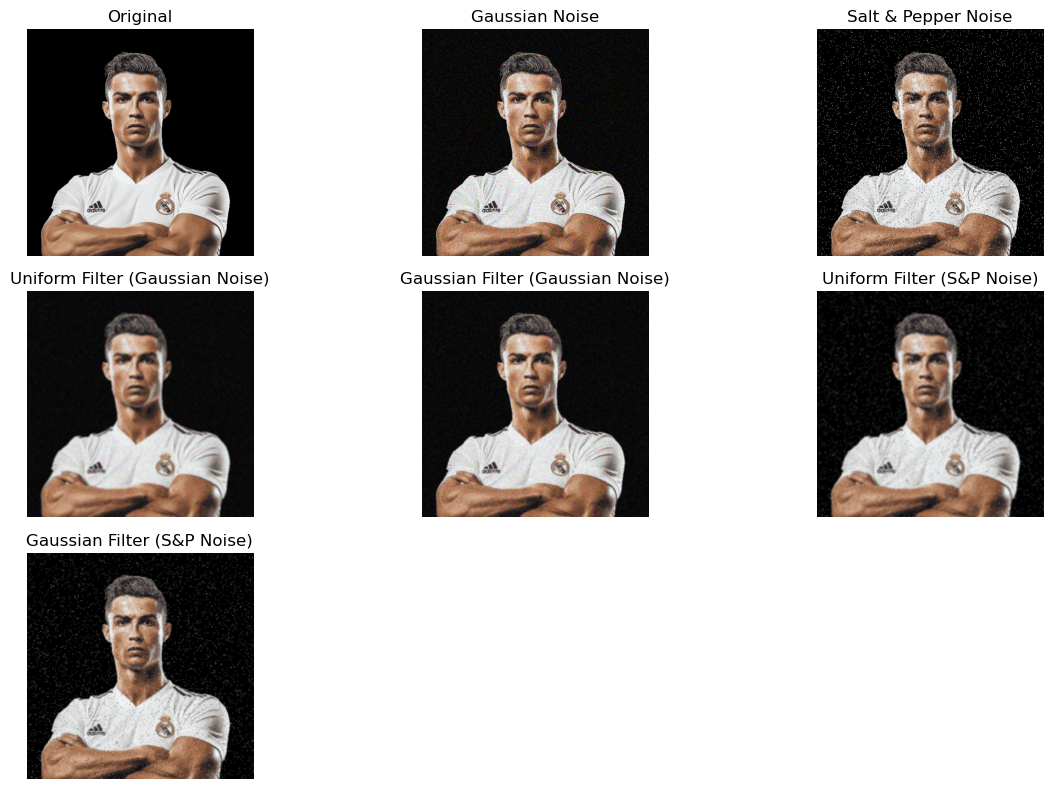

In [2]:
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt

img = cv2.imread("/Users/230166/Desktop/picture.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


mean = 0
sigma = 25
gaussian_noise = np.random.normal(mean, sigma, img.shape)

noisy_gaussian = img + gaussian_noise
noisy_gaussian = np.clip(noisy_gaussian, 0, 255).astype(np.uint8)

noisy_sp = img.copy()
prob = 0.02

for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        r = random.random()
        if r < prob:
            noisy_sp[i][j] = 0
        elif r > 1 - prob:
            noisy_sp[i][j] = 255

uniform_gaussian = cv2.blur(noisy_gaussian, (5,5))
uniform_sp = cv2.blur(noisy_sp, (5,5))


gaussian_gaussian = cv2.GaussianBlur(noisy_gaussian, (5,5), 1)
gaussian_sp = cv2.GaussianBlur(noisy_sp, (5,5), 1)

titles = [
    "Original",
    "Gaussian Noise",
    "Salt & Pepper Noise",
    "Uniform Filter (Gaussian Noise)",
    "Gaussian Filter (Gaussian Noise)",
    "Uniform Filter (S&P Noise)",
    "Gaussian Filter (S&P Noise)"
]

images = [
    img,
    noisy_gaussian,
    noisy_sp,
    uniform_gaussian,
    gaussian_gaussian,
    uniform_sp,
    gaussian_sp
]

plt.figure(figsize=(12,8))

for i in range(len(images)):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()


Average Edge Strength:
Original: 22.784408
Box Filter: 13.169024
Gaussian Filter: 15.03536


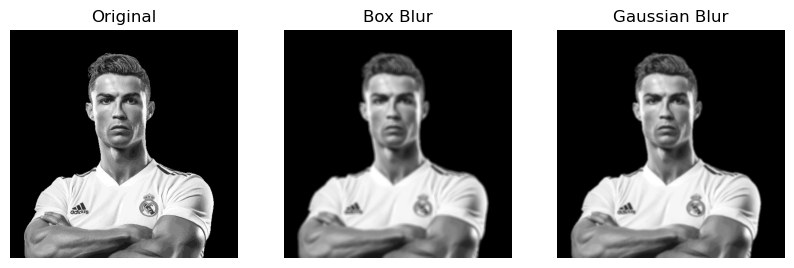

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


img = cv2.imread("/Users/230166/Desktop/picture.png", cv2.IMREAD_GRAYSCALE)


box_blur = cv2.blur(img, (7,7))


gaussian_blur = cv2.GaussianBlur(img, (7,7), 1.5)


sobel_original = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobel_box = cv2.Sobel(box_blur, cv2.CV_64F, 1, 0, ksize=3)
sobel_gaussian = cv2.Sobel(gaussian_blur, cv2.CV_64F, 1, 0, ksize=3)


sobel_original = np.absolute(sobel_original)
sobel_box = np.absolute(sobel_box)
sobel_gaussian = np.absolute(sobel_gaussian)

edge_original = np.mean(sobel_original)
edge_box = np.mean(sobel_box)
edge_gaussian = np.mean(sobel_gaussian)

print("Average Edge Strength:")
print("Original:", edge_original)
print("Box Filter:", edge_box)
print("Gaussian Filter:", edge_gaussian)


titles = ["Original", "Box Blur", "Gaussian Blur"]
images = [img, box_blur, gaussian_blur]

plt.figure(figsize=(10,5))

for i in range(3):
    plt.subplot(1,3,i+1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.show()

In [6]:
import cv2
import numpy as np
import time


img = cv2.imread("/Users/230166/Desktop/picture.png", cv2.IMREAD_GRAYSCALE)

kernel = cv2.getGaussianKernel(7, 1.5)
kernel = kernel @ kernel.T   # 2D Gaussian kernel

runs = 100

filter2d_times = []

for i in range(runs):
    start = time.time()
    result = cv2.filter2D(img, -1, kernel)
    end = time.time()
    filter2d_times.append(end - start)

avg_filter2d = sum(filter2d_times) / runs


gaussian_times = []

for i in range(runs):
    start = time.time()
    result = cv2.GaussianBlur(img, (7,7), 1.5)
    end = time.time()
    gaussian_times.append(end - start)

avg_gaussian = sum(gaussian_times) / runs

print("average execution time")
print("filter2D:", avg_filter2d)
print("gaussian blur:", avg_gaussian)

average execution time
filter2D: 0.001188383102416992
gaussian blur: 0.00014932632446289064


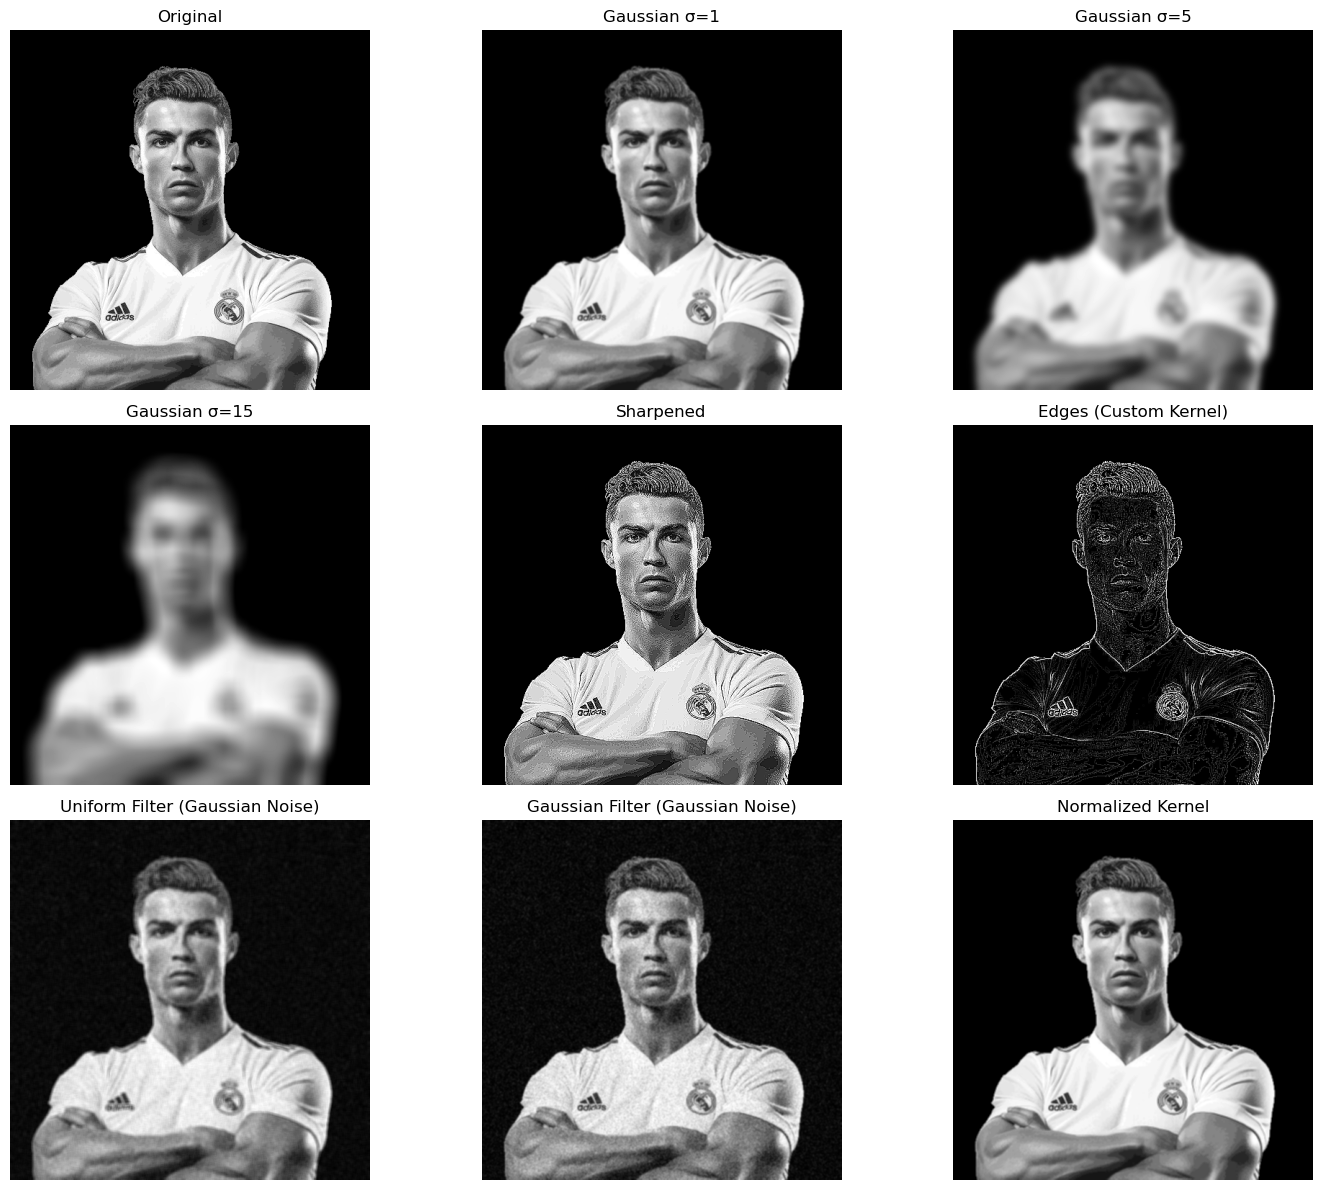

Average Edge Strengths (Challenge 5):
Original: 22.78
Box Filter: 13.17
Gaussian Filter: 15.04

Average Execution Time (Challenge 6):
filter2D: 0.001029 sec
GaussianBlur: 0.000138 sec


In [7]:
import cv2
import numpy as np
import random
import time
import matplotlib.pyplot as plt

img = cv2.imread("/Users/230166/Desktop/picture.png", cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Error: Image not found. Check the file path.")
    exit()


sigma_values = [1, 5, 15]
ksize = (31,31)
gaussian_blurs = [cv2.GaussianBlur(img, ksize, s) for s in sigma_values]


# Sharpen kernel
sharpen_kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharpened = cv2.filter2D(img, -1, sharpen_kernel)

# Edge detection kernel
edge_kernel = np.array([[-1,-1,-1],[-1,8,-1],[-1,-1,-1]])
edges = cv2.filter2D(img, -1, edge_kernel)


# Gaussian noise
mean, sigma = 0, 25
gaussian_noise = img + np.random.normal(mean, sigma, img.shape)
gaussian_noise = np.clip(gaussian_noise,0,255).astype(np.uint8)

# Salt & Pepper noise
noisy_sp = img.copy()
prob = 0.02
for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        r = random.random()
        if r < prob:
            noisy_sp[i][j] = 0
        elif r > 1 - prob:
            noisy_sp[i][j] = 255

# Uniform filter
uniform_gaussian = cv2.blur(gaussian_noise, (5,5))
uniform_sp = cv2.blur(noisy_sp, (5,5))

# Gaussian filter
gaussian_gaussian = cv2.GaussianBlur(gaussian_noise, (5,5), 1)
gaussian_sp = cv2.GaussianBlur(noisy_sp, (5,5), 1)


box_blur = cv2.blur(img, (7,7))
gaussian_blur = cv2.GaussianBlur(img, (7,7), 1.5)

sobel_original = np.absolute(cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3))
sobel_box = np.absolute(cv2.Sobel(box_blur, cv2.CV_64F, 1, 0, ksize=3))
sobel_gaussian = np.absolute(cv2.Sobel(gaussian_blur, cv2.CV_64F, 1, 0, ksize=3))

avg_edges = {
    "Original": np.mean(sobel_original),
    "Box Filter": np.mean(sobel_box),
    "Gaussian Filter": np.mean(sobel_gaussian)
}


kernel = cv2.getGaussianKernel(7,1.5)
kernel = kernel @ kernel.T
runs = 50

# filter2D
filter2d_times = []
for _ in range(runs):
    start = time.time()
    _ = cv2.filter2D(img, -1, kernel)
    filter2d_times.append(time.time()-start)
avg_filter2d = sum(filter2d_times)/runs

# GaussianBlur
gaussian_times = []
for _ in range(runs):
    start = time.time()
    _ = cv2.GaussianBlur(img, (7,7), 1.5)
    gaussian_times.append(time.time()-start)
avg_gaussian = sum(gaussian_times)/runs


kernel_non_normalized = np.ones((3,3))
result_non_normalized = cv2.filter2D(img, -1, kernel_non_normalized)

kernel_normalized = kernel_non_normalized / np.sum(kernel_non_normalized)
result_normalized = cv2.filter2D(img, -1, kernel_normalized)


plt.figure(figsize=(15,12))

plt.subplot(3,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

# Challenge 2
for i,s in enumerate(sigma_values):
    plt.subplot(3,3,i+2)
    plt.imshow(gaussian_blurs[i], cmap='gray')
    plt.title(f"Gaussian σ={s}")
    plt.axis('off')

plt.subplot(3,3,5)
plt.imshow(sharpened, cmap='gray')
plt.title("Sharpened")
plt.axis('off')

plt.subplot(3,3,6)
plt.imshow(edges, cmap='gray')
plt.title("Edges (Custom Kernel)")
plt.axis('off')

plt.subplot(3,3,7)
plt.imshow(uniform_gaussian, cmap='gray')
plt.title("Uniform Filter (Gaussian Noise)")
plt.axis('off')

plt.subplot(3,3,8)
plt.imshow(gaussian_gaussian, cmap='gray')
plt.title("Gaussian Filter (Gaussian Noise)")
plt.axis('off')

plt.subplot(3,3,9)
plt.imshow(result_normalized, cmap='gray')
plt.title("Normalized Kernel")
plt.axis('off')

plt.tight_layout()
plt.show()

print("Average Edge Strengths (Challenge 5):")
for k,v in avg_edges.items():
    print(f"{k}: {v:.2f}")

print("\nAverage Execution Time (Challenge 6):")
print(f"filter2D: {avg_filter2d:.6f} sec")
print(f"GaussianBlur: {avg_gaussian:.6f} sec")

Enter image file path:  /Users/230166/Desktop/picture.png
Choose filter type ('uniform' or 'gaussian'):  guassian


Invalid input. Please enter 'uniform' or 'gaussian'.


Choose filter type ('uniform' or 'gaussian'):  gaussian
Enter kernel size (odd integer, e.g., 3,5,7):  7
Enter sigma for Gaussian filter (e.g., 1.0, 2.5):  2.5


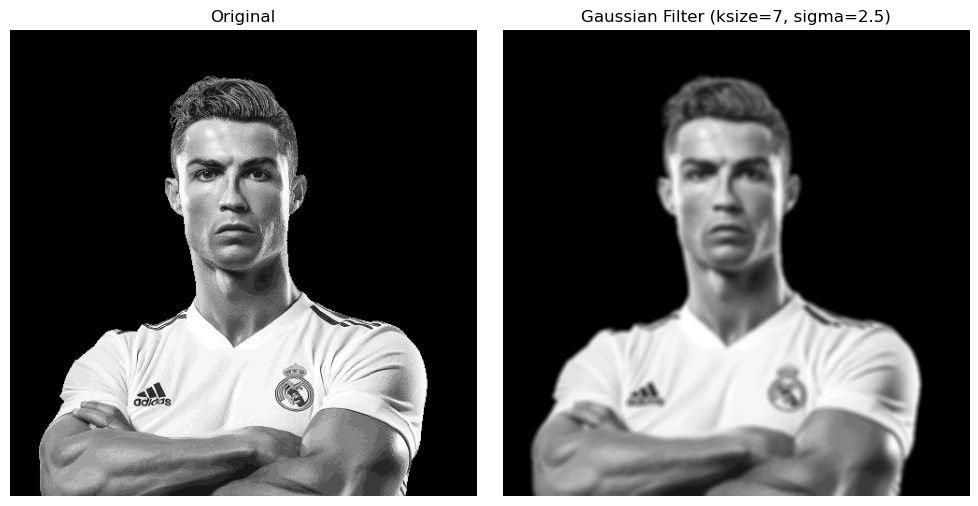

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def get_user_input():
    """
    Ask the user which filter to apply and relevant parameters.
    Returns:
        filter_type (str): "uniform" or "gaussian"
        ksize (int): kernel size (must be odd)
        sigma (float): sigma value for Gaussian (ignored for uniform)
    """
    while True:
        filter_type = input("Choose filter type ('uniform' or 'gaussian'): ").strip().lower()
        if filter_type in ['uniform', 'gaussian']:
            break
        print("Invalid input. Please enter 'uniform' or 'gaussian'.")

    while True:
        try:
            ksize = int(input("Enter kernel size (odd integer, e.g., 3,5,7): "))
            if ksize % 2 == 1 and ksize > 0:
                break
            print("Kernel size must be a positive odd integer.")
        except ValueError:
            print("Invalid input. Please enter an integer.")

    sigma = 0
    if filter_type == 'gaussian':
        while True:
            try:
                sigma = float(input("Enter sigma for Gaussian filter (e.g., 1.0, 2.5): "))
                if sigma > 0:
                    break
                print("Sigma must be positive.")
            except ValueError:
                print("Invalid input. Please enter a number.")

    return filter_type, ksize, sigma

def apply_filter(img, filter_type, ksize, sigma=0):
    """
    Applies the selected filter to the image.
    Args:
        img (np.ndarray): Input image
        filter_type (str): "uniform" or "gaussian"
        ksize (int): Kernel size
        sigma (float): Gaussian sigma (ignored for uniform)
    Returns:
        filtered_img (np.ndarray): Filtered image
    """
    if filter_type == 'uniform':
        filtered_img = cv2.blur(img, (ksize, ksize))
    else:  # Gaussian
        filtered_img = cv2.GaussianBlur(img, (ksize, ksize), sigma)
    return filtered_img

def display_side_by_side(original, filtered, title_filtered):
    """
    Displays original and filtered images side by side using Matplotlib.
    """
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.imshow(original, cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(filtered, cmap='gray')
    plt.title(title_filtered)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

def main():
    # Load image
    img_path = input("Enter image file path: ").strip()
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("Error: Could not load image. Check file path.")
        return

    # Get user parameters
    filter_type, ksize, sigma = get_user_input()

    # Apply selected filter
    filtered_img = apply_filter(img, filter_type, ksize, sigma)

    # Display results
    title = f"{filter_type.capitalize()} Filter (ksize={ksize}"
    if filter_type == "gaussian":
        title += f", sigma={sigma})"
    else:
        title += ")"

    display_side_by_side(img, filtered_img, title)

if __name__ == "__main__":
    main()